# 6. Comparación Final de Modelos — Benchmark

Comparación side-by-side de los **5 modelos** entrenados en los notebooks 1-5:
1. Popularity (baseline no-personalizado)
2. Content-Based (similitud de contenido)
3. Collaborative Filtering (ganador del notebook 3)
4. PMLP (personalidad, cold-start)
5. Hybrid (Rank Fusion de los 4 anteriores)

Se cargan todos desde disco — no se re-entrena nada.

In [1]:
import json as _json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from tabulate import tabulate

sys.path.insert(0, str(Path.cwd().parent.parent))
import ml.config as cfg
from ml.evaluation import notebook_utils as nu
from ml.evaluation.splits import movielens_split
from ml.models.base import BaseRecommender
from ml.models.popularity import PopularityRecommender
from ml.models.content_based import ContentBasedRecommender
from ml.models.lightgcn import LightGCN
from ml.models.bprmf import BPRMF
from ml.models.surprise_svd import SurpriseSVD, SurpriseSVDpp
from ml.models.personality import PersonalityMLPRecommender

K = 10
SAVED_DIR = Path('..') / 'models' / 'saved'
N_ITEMS = cfg.catalog_size()
cosine_sim = cfg.load_cosine_sim()
popularity = cfg.load_popularity()
train, test = movielens_split(cfg.RATINGS_PATH)
movies_df = pd.read_csv(cfg.MOVIES_PATH)
print(f'train={len(train):,}  test={len(test):,}  N_ITEMS={N_ITEMS}')


train=797,809  test=108,298  N_ITEMS=3830


## 1. Carga de modelos desde disco

In [2]:
# 1. Popularity
pop_model = PopularityRecommender.load(SAVED_DIR / 'popularity.pkl')
pop_model.fit(train)
print('✓ Popularity')

# 2. Content-Based
with open(SAVED_DIR / 'content_based_meta.json') as f:
    cb_meta = _json.load(f)
cb_model = ContentBasedRecommender(
    cosine_sim_path=cfg.COSINE_SIM_PATH, movies_path=cfg.MOVIES_PATH,
    cosine_sim=cosine_sim, **cb_meta['hyperparameters'],
)
cb_model.fit(train)
print('✓ Content-Based')

# 3. CF
with open(SAVED_DIR / 'collaborative_meta.json') as f:
    cf_meta = _json.load(f)
cf_name = cf_meta['model']
if cf_name == 'LightGCN':
    cf_model = LightGCN.load(SAVED_DIR / 'collaborative.npz')
else:
    cf_model = pickle.load(open(SAVED_DIR / 'collaborative.pkl', 'rb'))
cf_model._seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    cf_model._seen.setdefault(int(uid), set()).add(int(mid))
print(f'✓ {cf_name}')

# 4. PMLP — cargar modelo + inyectar personalidades del benchmark
with open(SAVED_DIR / 'pmlp_sv.pkl', 'rb') as f:
    pmlp_model = pickle.load(f)
ratings_raw = pd.read_parquet(cfg.RATINGS_PATH)
pers_bench = cfg.derive_personalities(
    ratings_raw[['user_id', 'movie_id', 'rating']], pd.read_csv(cfg.MOVIES_PATH),
)
pmlp_model.set_personalities(pers_bench)
pmlp_model._user_seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    pmlp_model._user_seen.setdefault(int(uid), set()).add(int(mid))
print(f'✓ PMLP ({len(pmlp_model._traits)} usuarios con personalidad)')

# 5. Hybrid
with open(SAVED_DIR / 'hybrid_meta.json') as f:
    hybrid_meta = _json.load(f)
hybrid_weights = list(hybrid_meta['weights'].values())

RRF_K = 60
class HybridRankFusionRecommender(BaseRecommender):
    def __init__(self, models, weights):
        self._models = models
        self._weights = np.array(weights, dtype=np.float64)
        self._user_seen = {}
    def fit(self, ratings):
        self._user_seen = {}
        for uid, mid in zip(ratings['user_id'].values, ratings['movie_idx'].values):
            self._user_seen.setdefault(int(uid), set()).add(int(mid))
        for m in self._models:
            m.fit(ratings)
    def score_all(self, user_id):
        max_len = max((len(s) for m in self._models if (s := m.score_all(user_id)) is not None), default=0)
        if max_len == 0: return None
        rs = np.zeros(max_len, dtype=np.float64)
        for m, w in zip(self._models, self._weights):
            s = m.score_all(user_id)
            if s is None: continue
            ranks = np.empty(len(s), dtype=np.float64)
            ranks[np.argsort(-s)] = np.arange(1, len(s)+1)
            rs[:len(s)] += w / (RRF_K + ranks)
        return rs.astype(np.float32)
    def recommend(self, user_id, n=10, exclude=None):
        scores = self.score_all(user_id)
        if scores is None: return []
        seen = set(self._user_seen.get(user_id, set()))
        if exclude: seen |= exclude
        scores = scores.copy()
        for idx in seen:
            if 0 <= idx < len(scores): scores[idx] = -np.inf
        return np.argsort(-scores)[:n].tolist()

model_list = [pop_model, cb_model, cf_model, pmlp_model]
hybrid_model = HybridRankFusionRecommender(model_list, hybrid_weights)
hybrid_model._user_seen = {}
for uid, mid in zip(train['user_id'].values, train['movie_idx'].values):
    hybrid_model._user_seen.setdefault(int(uid), set()).add(int(mid))

all_models = {
    'Popularity': pop_model,
    'Content-Based': cb_model,
    cf_name: cf_model,
    'PMLP': pmlp_model,
    'Hybrid': hybrid_model,
}
print(f'\n{len(all_models)} modelos cargados: {list(all_models.keys())}')


✓ Popularity
✓ Content-Based
✓ LightGCN
✓ PMLP (6000 usuarios con personalidad)

5 modelos cargados: ['Popularity', 'Content-Based', 'LightGCN', 'PMLP', 'Hybrid']


## 2. Evaluación full-catalog (Benchmark, K=10)

In [3]:
class _NoFit:
    def __init__(self, m): self._m = m
    def fit(self, *a, **k): pass
    def recommend(self, *a, **k): return self._m.recommend(*a, **k)
    def score_all(self, *a, **k): return self._m.score_all(*a, **k)

all_results = {}
for name, model in all_models.items():
    print(f'Evaluando {name}...')
    all_results[name] = nu.evaluate_movielens(
        _NoFit(model), train, test, K, cosine_sim, popularity, N_ITEMS,
    )
    print(f'  NDCG@{K}: {all_results[name]["ndcg"]:.4f}')
print('Done')


Evaluando Popularity...
  NDCG@10: 0.1345
Evaluando Content-Based...
  NDCG@10: 0.1194
Evaluando LightGCN...
  NDCG@10: 0.3079
Evaluando PMLP...
  NDCG@10: 0.2371
Evaluando Hybrid...
  NDCG@10: 0.3387
Done


## 3. Tabla comparativa

In [4]:
metrics = ['precision', 'recall', 'ndcg', 'diversity', 'novelty', 'coverage']
rows = []
for name, res in all_results.items():
    rows.append([name] + [f'{res[m]:.4f}' for m in metrics])
headers = ['Modelo'] + [m.capitalize() + '@K' for m in metrics]
print(tabulate(rows, headers=headers, tablefmt='fancy_grid'))


╒═══════════════╤═══════════════╤════════════╤══════════╤═══════════════╤═════════════╤══════════════╕
│ Modelo        │   Precision@K │   Recall@K │   Ndcg@K │   Diversity@K │   Novelty@K │   Coverage@K │
╞═══════════════╪═══════════════╪════════════╪══════════╪═══════════════╪═════════════╪══════════════╡
│ Popularity    │        0.1143 │     0.1206 │   0.1345 │        0.4318 │      0.1092 │       0.0125 │
├───────────────┼───────────────┼────────────┼──────────┼───────────────┼─────────────┼──────────────┤
│ Content-Based │        0.0922 │     0.0968 │   0.1194 │        0.3605 │      0.5161 │       0.4601 │
├───────────────┼───────────────┼────────────┼──────────┼───────────────┼─────────────┼──────────────┤
│ LightGCN      │        0.2664 │     0.2808 │   0.3079 │        0.4072 │      0.5182 │       0.4807 │
├───────────────┼───────────────┼────────────┼──────────┼───────────────┼─────────────┼──────────────┤
│ PMLP          │        0.2009 │     0.2119 │   0.2371 │        0.4352 │

## 4. Gráficas por métrica

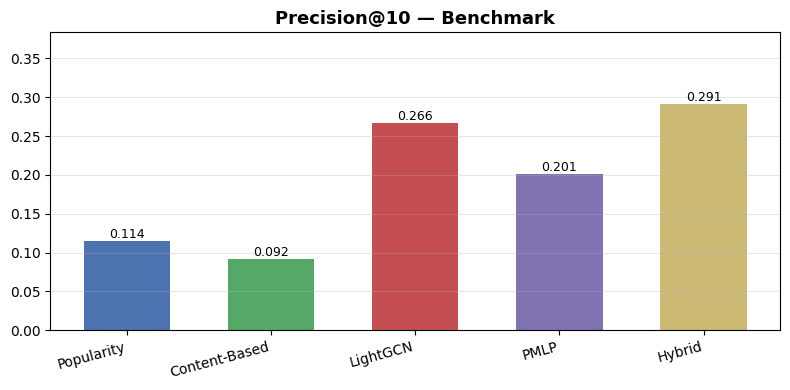

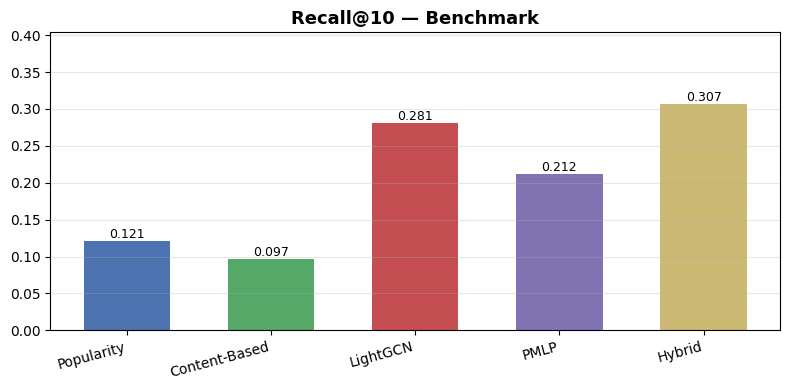

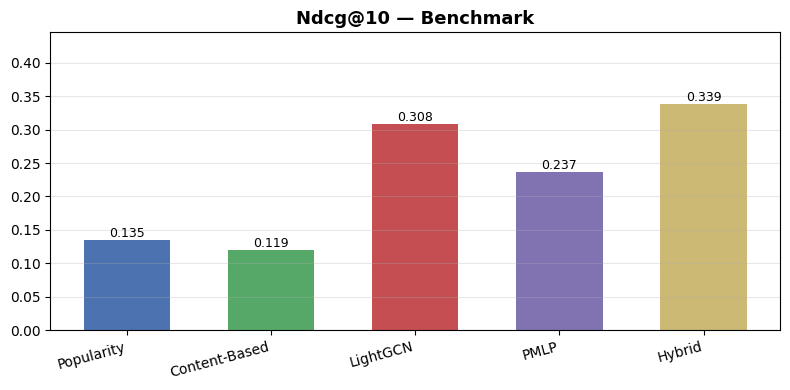

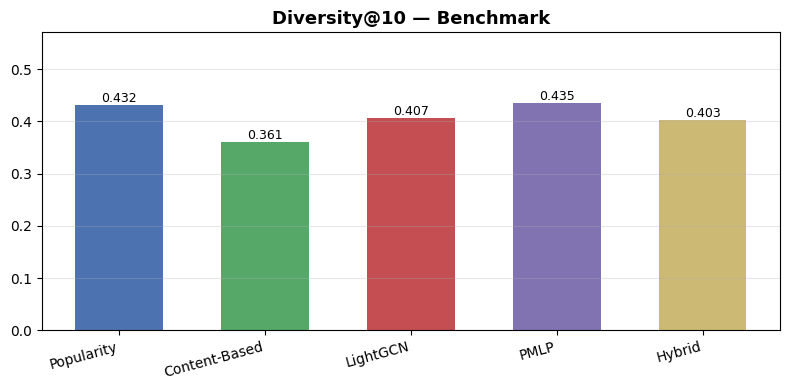

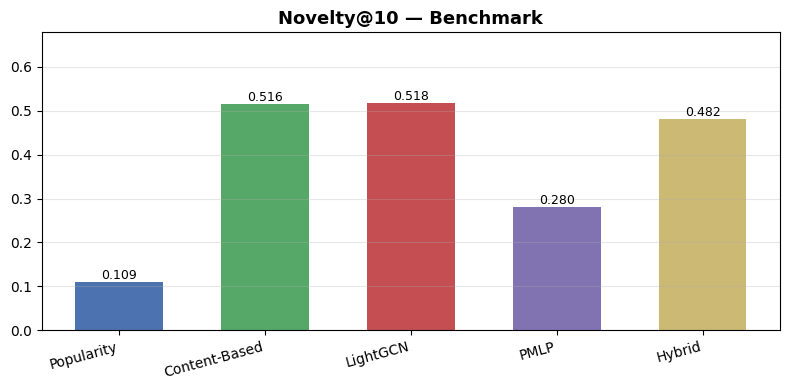

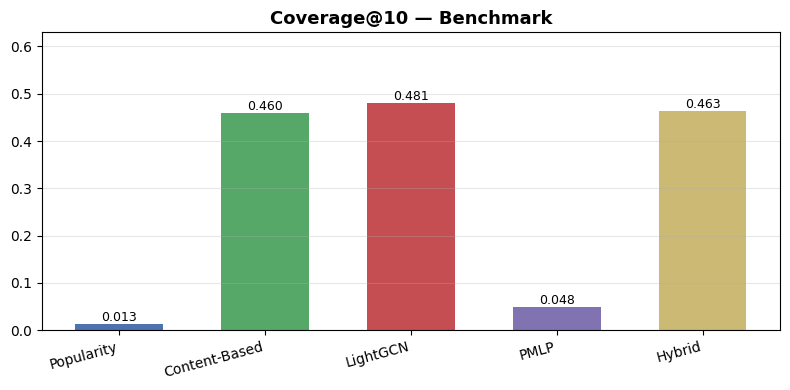

In [5]:
model_names = list(all_results.keys())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
metrics = ['precision', 'recall', 'ndcg', 'diversity', 'novelty', 'coverage']

for metric in metrics:
    vals = [all_results[n][metric] for n in model_names]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(model_names))
    bars = ax.bar(x, vals, color=colors, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
    ax.set_title(f'{metric.capitalize()}@{K} — Benchmark', fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3 + 0.005)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()


## 5. Evaluación Survey (sampled LOO, 1+99)

Se evalúan los 5 modelos sobre los usuarios reales del Survey con el protocolo leave-one-out sampled. Métricas: HR@K y NDCG@K.

In [6]:
from ml.evaluation.splits import survey_split_sampled

sv_folds = survey_split_sampled(
    nu.RATINGS_SURVEY_PATH, cfg.MOVIES_PATH, n_negatives=99, seed=42,
)
print(f'Survey folds: {len(sv_folds)}')

# ── Preparar factories ──────────────────────────────────────────────
# Cada factory crea una instancia FRESCA que evaluate_survey re-entrena por fold.

# CF hyperparams del notebook 3
cf_hp = {k: (int(v) if isinstance(v, float) and v == int(v) else v)
         for k, v in cf_meta['hyperparameters'].items()}
_cf_cls = {'LightGCN': LightGCN, 'BPR-MF': BPRMF,
           'SVD': SurpriseSVD, 'SVD++': SurpriseSVDpp}[cf_name]

# Content-Based hyperparams
_cb_hp = cb_meta['hyperparameters']
_cs = cosine_sim

# PMLP: necesita personalidades del Survey (userid → user_id) + item embeddings
# Los item embeddings vienen del LightGCN del notebook 4 (64 dims), NO del CF del notebook 3 (128 dims)
_pers_sv = pd.read_csv(nu._ML_DIR / 'data' / 'DataNewUsers' / 'personalities.csv')
_pers_sv = _pers_sv.rename(columns={'userid': 'user_id'})

lgcn_nb4 = LightGCN.load(SAVED_DIR / 'lightgcn_benchmark.npz')
_Ei_raw = lgcn_nb4._Ei_final
_Ei = np.zeros((N_ITEMS, _Ei_raw.shape[1]), dtype=np.float32)
_Ei[:_Ei_raw.shape[0]] = _Ei_raw
_emb_dim = _Ei_raw.shape[1]
print(f'PMLP item embeddings: {_Ei.shape} (from LightGCN nb4, {_emb_dim}d)')

with open(SAVED_DIR / 'personality_meta.json') as f:
    _pmlp_meta = _json.load(f)
_pmlp_hp = _pmlp_meta['pmlp_sv']

def _make_pmlp():
    return PersonalityMLPRecommender(
        personalities=_pers_sv, cf_item_embeddings=_Ei,
        embedding_dim=_emb_dim, batch_size=256, patience=5, seed=42, **_pmlp_hp,
    )

def _make_hybrid():
    return HybridRankFusionRecommender(
        [PopularityRecommender(cfg.MOVIES_PATH),
         ContentBasedRecommender(cosine_sim_path=cfg.COSINE_SIM_PATH,
                                 movies_path=cfg.MOVIES_PATH, cosine_sim=_cs, **_cb_hp),
         _cf_cls(**cf_hp),
         _make_pmlp()],
        hybrid_weights,
    )

factories = {
    'Popularity': lambda: PopularityRecommender(cfg.MOVIES_PATH),
    'Content-Based': lambda: ContentBasedRecommender(
        cosine_sim_path=cfg.COSINE_SIM_PATH, movies_path=cfg.MOVIES_PATH,
        cosine_sim=_cs, **_cb_hp),
    cf_name: lambda: _cf_cls(**cf_hp),
    'PMLP': _make_pmlp,
    'Hybrid': _make_hybrid,
}

survey_results = {}
for name, factory in factories.items():
    print(f'Evaluando {name} en Survey...')
    survey_results[name] = nu.evaluate_survey(
        model_factory=factory, folds=sv_folds, k=K, n_items=N_ITEMS,
    )
    print(f'  HR@{K}: {survey_results[name]["hr"]:.4f}  '
          f'NDCG@{K}: {survey_results[name]["ndcg"]:.4f}')


Survey folds: 118
PMLP item embeddings: (3830, 64) (from LightGCN nb4, 64d)
Evaluando Popularity en Survey...
  HR@10: 0.8729  NDCG@10: 0.6179
Evaluando Content-Based en Survey...
  HR@10: 0.6356  NDCG@10: 0.4262
Evaluando LightGCN en Survey...
  HR@10: 1.0000  NDCG@10: 0.7946
Evaluando PMLP en Survey...
  HR@10: 0.9492  NDCG@10: 0.6879
Evaluando Hybrid en Survey...
  HR@10: 1.0000  NDCG@10: 0.8046


### Tabla Survey

In [7]:
rows = []
for name, res in survey_results.items():
    rows.append([name, f'{res["hr"]:.4f}', f'{res["ndcg"]:.4f}'])
print(tabulate(rows, headers=['Modelo', f'HR@{K}', f'NDCG@{K}'], tablefmt='fancy_grid'))


╒═══════════════╤═════════╤═══════════╕
│ Modelo        │   HR@10 │   NDCG@10 │
╞═══════════════╪═════════╪═══════════╡
│ Popularity    │  0.8729 │    0.6179 │
├───────────────┼─────────┼───────────┤
│ Content-Based │  0.6356 │    0.4262 │
├───────────────┼─────────┼───────────┤
│ LightGCN      │  1      │    0.7946 │
├───────────────┼─────────┼───────────┤
│ PMLP          │  0.9492 │    0.6879 │
├───────────────┼─────────┼───────────┤
│ Hybrid        │  1      │    0.8046 │
╘═══════════════╧═════════╧═══════════╛


╒═══════════════╤═════════╤═══════════╕
│ Modelo        │   HR@10 │   NDCG@10 │
╞═══════════════╪═════════╪═══════════╡
│ Popularity    │  0.8729 │    0.5903 │
├───────────────┼─────────┼───────────┤
│ Content-Based │  0.6186 │    0.4169 │
├───────────────┼─────────┼───────────┤
│ LightGCN      │  1      │    0.7761 │
├───────────────┼─────────┼───────────┤
│ PMLP          │  0.9407 │    0.6622 │
├───────────────┼─────────┼───────────┤
│ Hybrid        │  1      │    0.7905 │
╘═══════════════╧═════════╧═══════════╛

### Gráficas Survey

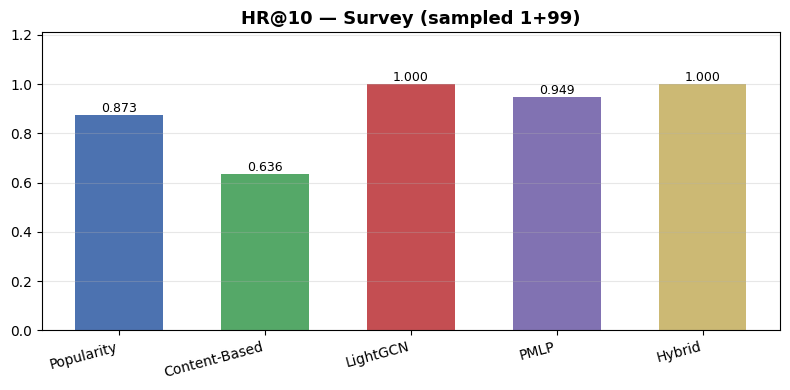

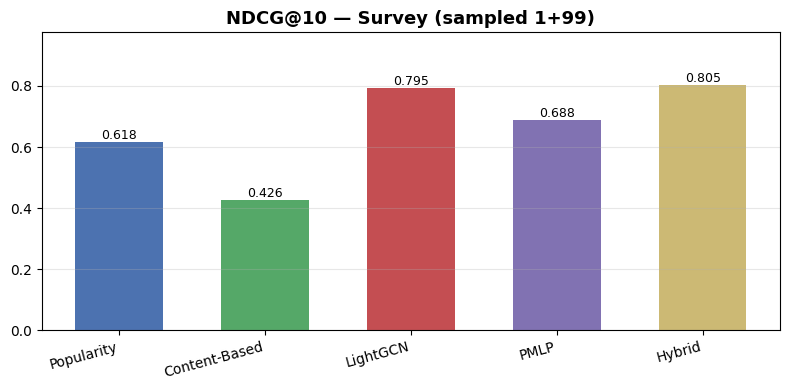

In [8]:
model_names = list(survey_results.keys())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

for metric in ['hr', 'ndcg']:
    vals = [survey_results[n][metric] for n in model_names]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(model_names))
    bars = ax.bar(x, vals, color=colors, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
    label = 'HR' if metric == 'hr' else 'NDCG'
    ax.set_title(f'{label}@{K} — Survey (sampled 1+99)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2 + 0.01)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()


## 7. Ejemplos de recomendaciones por usuario

Para los mismos 3 usuarios de los notebooks anteriores: sus 5 películas favoritas y las 10 recomendaciones de cada modelo side-by-side.

In [9]:
lookup = {int(r.movie_id): r.title for r in movies_df.itertuples(index=False)}

rng_ex = np.random.default_rng(42)
sample_users = rng_ex.choice(test['user_id'].unique(), size=3, replace=False).tolist()
model_names = list(all_models.keys())

for uid in sample_users:
    display(Markdown(f'---\n## Usuario {uid}'))

    # Top-5 favourites
    user_train = train[train['user_id'] == uid].sort_values('rating', ascending=False).head(5)
    fav_rows = []
    for rank, (_, r) in enumerate(user_train.iterrows(), 1):
        fav_rows.append([rank, lookup.get(int(r['movie_idx']), '?'), f'{r["rating"]:.1f}'])
    display(Markdown('**Top-5 películas favoritas (en train):**'))
    print(tabulate(fav_rows, headers=['#', 'Título', 'Rating'], tablefmt='fancy_grid'))

    # Recommendations from each model
    recs_per_model = {}
    for name, model in all_models.items():
        recs_per_model[name] = model.recommend(int(uid), n=K)

    # Build side-by-side table: 10 rows, one column per model
    rows = []
    for rank in range(K):
        row = [rank + 1]
        for name in model_names:
            recs = recs_per_model[name]
            if rank < len(recs):
                row.append(lookup.get(int(recs[rank]), '?'))
            else:
                row.append('—')
        rows.append(row)

    display(Markdown(f'**Top-{K} recomendaciones por modelo:**'))
    print(tabulate(rows, headers=['#'] + model_names, tablefmt='fancy_grid',
                   maxcolwidths=[4] + [25]*len(model_names)))


---
## Usuario 3927

**Top-5 películas favoritas (en train):**

╒═════╤═══════════════════════════════════════╤══════════╕
│   # │ Título                                │   Rating │
╞═════╪═══════════════════════════════════════╪══════════╡
│   1 │ The Way Way Back                      │        5 │
├─────┼───────────────────────────────────────┼──────────┤
│   2 │ Bridesmaids                           │        5 │
├─────┼───────────────────────────────────────┼──────────┤
│   3 │ Ocean's Thirteen                      │        5 │
├─────┼───────────────────────────────────────┼──────────┤
│   4 │ Anchorman: The Legend of Ron Burgundy │        5 │
├─────┼───────────────────────────────────────┼──────────┤
│   5 │ National Treasure: Book of Secrets    │        5 │
╘═════╧═══════════════════════════════════════╧══════════╛


**Top-10 recomendaciones por modelo:**

╒═════╤════════════════════════╤══════════════════════════╤═════════════════════╤══════════════════════════╤═════════════════╕
│   # │ Popularity             │ Content-Based            │ LightGCN            │ PMLP                     │ Hybrid          │
╞═════╪════════════════════════╪══════════════════════════╪═════════════════════╪══════════════════════════╪═════════════════╡
│   1 │ The Lord of the Rings: │ Zombieland: Double Tap   │ Easy A              │ The Hundred-Foot Journey │ Easy A          │
│     │ The Return of the King │                          │                     │                          │                 │
├─────┼────────────────────────┼──────────────────────────┼─────────────────────┼──────────────────────────┼─────────────────┤
│   2 │ Fight Club             │ Toy Story 4              │ Hitch               │ Frozen II                │ Hitch           │
├─────┼────────────────────────┼──────────────────────────┼─────────────────────┼──────────────────────────┼───

...

---
## Usuario 4641

**Top-5 películas favoritas (en train):**

╒═════╤════════════════════════════════╤══════════╕
│   # │ Título                         │   Rating │
╞═════╪════════════════════════════════╪══════════╡
│   1 │ The Matrix                     │        5 │
├─────┼────────────────────────────────┼──────────┤
│   2 │ The Dawn Wall                  │        5 │
├─────┼────────────────────────────────┼──────────┤
│   3 │ Parasite                       │        5 │
├─────┼────────────────────────────────┼──────────┤
│   4 │ La Maison en Petits Cubes      │        5 │
├─────┼────────────────────────────────┼──────────┤
│   5 │ Guardians of the Galaxy Vol. 2 │        5 │
╘═════╧════════════════════════════════╧══════════╛


**Top-10 recomendaciones por modelo:**

╒═════╤════════════════════════╤══════════════════════════╤══════════════════════════╤═════════════════════════╤══════════════════════════╕
│   # │ Popularity             │ Content-Based            │ LightGCN                 │ PMLP                    │ Hybrid                   │
╞═════╪════════════════════════╪══════════════════════════╪══════════════════════════╪═════════════════════════╪══════════════════════════╡
│   1 │ Interstellar           │ John Wick: Chapter 2     │ Star Trek: First Contact │ Fight Club              │ Avengers: Infinity War   │
├─────┼────────────────────────┼──────────────────────────┼──────────────────────────┼─────────────────────────┼──────────────────────────┤
│   2 │ The Lord of the Rings: │ John Wick: Chapter 3 -   │ Robot Chicken: Star Wars │ The Lord of the Rings:  │ Star Trek: First Contact │
│     │ The Return of the King │ Parabellum               │ Episode II               │ The Return of the King  │                          │
├─────┼─────────────